Calculate basic reproduction num of system

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def briere(T, c, T0, Tm):
    """Brière: c*T*(T-T0)*sqrt(Tm-T) for T0<T<Tm, else 0."""
    if (T > T0) and (T < Tm):
        return c * T * (T - T0) * np.sqrt(Tm - T)
    return 0.0

In [3]:
def oviposition_rate(temp):
    b0 = -5.3999
    b1 = 1.800160
    b2 = -2.12e-1
    b3 = 1.02e-2
    b4 = -1.51e-4
    delta = b0 + b1*temp + b2*temp**2 + b3*temp**3 + b4*temp**4
    return max(0.0, delta)

def larval_growth(T):
    b0 = -1.842702
    b1 = 8.29e-1
    b2 = -1.46e-1
    b3 = 1.31e-2
    b4 = -6.46e-4
    b5 = 1.79e-5
    b6 = -2.62e-7
    b7 = 1.5e-9
    sigmal = b0 + b1*T + b2*T**2 + b3*T**3 + b4*T**4 + b5*T**5 + b6*T**6 + b7*T**7
    return max(0.01, sigmal)

def pupal_growth(T):
    b0 = 1.9021
    b1 = -10.31110
    b2 = 2.050830
    b3 = -2.24e-1
    b4 = 1.47e-2
    b5 = -5.89e-4
    b6 = 1.41e-5
    b7 = -1.9e-7
    b8 = 1.0e-9
    sigmap = b0 + b1*T + b2*T**2 + b3*T**3 + b4*T**4 + b5*T**5 + b6*T**6 + b7*T**7 + b8*T**8
    return max(0.01, sigmap)

def aquatic_transition(temp):
    sigmal = larval_growth(temp)
    sigmap = pupal_growth(temp)
    gamma = 1.0 / ((1.0/sigmal) + (1.0/sigmap))
    return max(0.0, gamma)

def aquatic_mortality(temp):
    b0 = 2.130
    b1 = -3.797e-1
    b2 = 2.457e-2
    b3 = -6.778e-4
    b4 = 6.794e-6
    mu = b0 + b1*temp + b2*temp**2 + b3*temp**3 + b4*temp**4
    return max(1e-6, mu)

def adult_mortality(temp):
    b0 = 8.69e-1
    b1 = -1.59e-1
    b2 = 1.12e-2
    b3 = -3.41e-4
    b4 = 3.81e-6
    mu_m = b0 + b1*temp + b2*temp**2 + b3*temp**3 + b4*temp**4
    return max(1e-6, mu_m)

In [4]:
def mosquito_incubation_rate(T, Ts=135.0, Tm=14.0):
    denom = max(0.1, (Tm - T) / Ts)
    return max(0.0, 1.0 / denom)

In [5]:
def mosquito_dfe_equilibrium(C, k, delta, gamma, mu_a, mu_m, c_a=0.0, c_m=0.0):
    """
    Infection off => Me=Mi=0, and M = Ms.
    Equilibrium from your mosquito subsystem:
      0 = k*δ*(1 - Ma/C)*Ms - (γ + μa + c_a)*Ma
      0 = γ*Ma - (μm + c_m)*Ms

    Returns (Ma*, Ms*). If no positive equilibrium exists, returns (0,0).
    """
    if gamma <= 0:
        return 0.0, 0.0

    a = (mu_m + c_m) / gamma  # Ma = a * Ms

    denom = k * delta * a
    if denom <= 0:
        return 0.0, 0.0

    Ms = (C / denom) * (k * delta - a * (gamma + mu_a + c_a))
    if Ms <= 0:
        return 0.0, 0.0

    Ma = a * Ms
    return Ma, Ms

In [6]:
def calculate_r0(params, T):
    """
    Infected compartments order: [He, Hi, Me, Mi]

    Compute KL = -Tmat * Sigma^{-1}, R0 = spectral radius(KL).
    Returns (R0, diagnostics_dict).
    """
    # Human params
    N = params["N"]
    mu_h = params["mu_h"]
    theta_h = params["theta_h"]
    gamma_h = params["gamma_h"]

    # Controls / mosquito demography params
    k = params.get("k", 0.5)
    c_a = params.get("c_a", 0.0)
    c_m = params.get("c_m", 0.0)
    C = params["C0"]

    # Compute temperature-dependent entomology parameters by calling the functions
    delta = oviposition_rate(T)
    gamma = aquatic_transition(T)
    mu_a = aquatic_mortality(T)
    mu_m = adult_mortality(T)

    # Temperature-dependent transmission & biting
    b  = briere(T, params["b_c"],  params["b_T0"],  params["b_Tm"])
    bm = briere(T, params["bm_c"], params["bm_T0"], params["bm_Tm"])  # mosquito->human transmission
    bh = briere(T, params["bh_c"], params["bh_T0"], params["bh_Tm"])  # human->mosquito transmission

    # Temperature-dependent extrinsic incubation rate θm(T)
    theta_m = mosquito_incubation_rate(T, params["thetam_Tm"], params["thetam_Ts"])

    # Mosquito DFE (infection off)
    _, Ms_star = mosquito_dfe_equilibrium(C, k, delta, gamma, mu_a, mu_m, c_a=c_a, c_m=c_m)

    # Build Tmat (new infections)
    # Rows/cols: [He, Hi, Me, Mi]
    Tmat = np.zeros((4, 4))
    # New human exposures from infectious mosquitoes Mi:
    # dHe/dt new = b*bm*(Mi/N)*Hs, at DFE Hs=N => b*bm*Mi
    Tmat[0, 3] = b * bm
    # New mosquito exposures from infectious humans Hi:
    # dMe/dt new = b*bh*(Hi/N)*Ms, at DFE => b*bh*(Ms*/N)*Hi
    Tmat[2, 1] = b * bh * (Ms_star / max(N, 1.0))

    # Build Sigma (transitions/removals among infected states)
    Sigma = np.zeros((4, 4))

    # Humans: He -> Hi -> out
    Sigma[0, 0] = -(theta_h + mu_h)
    Sigma[1, 0] =  (theta_h)
    Sigma[1, 1] = -(gamma_h + mu_h)

    # Mosquitoes: Me -> Mi -> death
    Sigma[2, 2] = -(theta_m + mu_m + c_m)
    Sigma[3, 2] =  theta_m
    Sigma[3, 3] = -(mu_m + c_m)

    # Compute KL = -Tmat * Sigma^{-1} using solve (avoid explicit inverse)
    # If Sigma is singular, return NaN.
    try:
        Sigma_inv_T = np.linalg.solve(Sigma.T, Tmat.T).T  # equivalent to Tmat @ inv(Sigma)
        KL = -Sigma_inv_T
    except np.linalg.LinAlgError:
        return np.nan, {"reason": "Sigma singular", "T": T}

    # Compute eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eig(KL)
    real_eigvals = np.real(eigvals)
    R0 = float(np.max(real_eigvals))  # Dominant eigenvalue as R0

    # Find the index of the major (dominant) eigenvalue
    major_idx = np.argmax(real_eigvals)
    major_eigvec = np.real(eigvecs[:, major_idx])  # Real part of the eigenvector

    # Compute partial reproduction numbers for vector-borne model
    # R_mh: Number of humans infected by one infectious mosquito
    prob_me_to_mi = theta_m / (theta_m + mu_m + c_m)
    infectious_lifespan_mi = 1 / (mu_m + c_m)
    R_mh = (b * bm) * prob_me_to_mi * infectious_lifespan_mi

    # R_hm: Number of mosquitoes infected by one infectious human
    prob_he_to_hi = theta_h / (theta_h + mu_h)
    infectious_lifespan_hi = 1 / (gamma_h + mu_h)
    R_hm = (b * bh * (Ms_star / N)) * prob_he_to_hi * infectious_lifespan_hi

    # Theoretical R0 should be sqrt(R_mh * R_hm)
    R0_sqrt = np.sqrt(R_mh * R_hm)

    diag = {
        "T": T,
        "b": b, "bm": bm, "bh": bh,
        "theta_m": theta_m,
        "Ms_star": Ms_star,
        "eigvals": eigvals,
        "KL": KL,
        "major_eigvec": major_eigvec,
        "R_mh": R_mh,  # Mosquito to human
        "R_hm": R_hm,  # Human to mosquito
        "R0_sqrt": R0_sqrt
    }
    return R0, diag

In [7]:
def r0_vs_temperature(params, Tmin=5, Tmax=45, n=200):
    temps = np.linspace(Tmin, Tmax, n)
    r0s = np.empty_like(temps)
    for i, T in enumerate(temps):
        r0s[i], _ = calculate_r0(params, float(T))
    return temps, r0s


In [8]:

def plot_r0_curve(temps, r0s):
    plt.figure()
    plt.plot(temps, r0s)
    plt.axhline(1.0)
    plt.xlabel("Temperature (°C)")
    plt.ylabel("R0")
    plt.title("R0 vs Temperature (NGM)")
    plt.show()

In [9]:
params = {
    # Human
    "N": 256088.0,
    "mu_h": 3.605e-5,
    "theta_h": 0.125,
    "gamma_h": 0.125,

    # Controls / constants
    "k": 0.5,
    "c_a": 0.0,
    "c_m": 0.0,
    "C0": 0.1061326 * 102751.0,

    # Brière coefficients
    "b_c": 5.0366e-4,  "b_T0": 13.35, "b_Tm": 40.08,
    "bm_c": 6.5093e-4, "bm_T0": 12.22, "bm_Tm": 37.46,
    "bh_c": 1.0546e-3, "bh_T0": 17.05, "bh_Tm": 35.83,

    # Extrinsic incubation θ_m(T)
    "thetam_Tm": 14.0,
    "thetam_Ts": 135.0, 
}


Temperature: 5°C
R0 (spectral radius): 0.0000
R_mh (mosquito-to-human): 0.0000
R_hm (human-to-mosquito): 0.0000
R0 from sqrt(R_mh * R_hm): 0.0000
Next Generation Matrix (KL):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Major Eigenvector:
 [1. 0. 0. 0.]

Temperature: 6°C
R0 (spectral radius): 0.0000
R_mh (mosquito-to-human): 0.0000
R_hm (human-to-mosquito): 0.0000
R0 from sqrt(R_mh * R_hm): 0.0000
Next Generation Matrix (KL):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Major Eigenvector:
 [1. 0. 0. 0.]

Temperature: 7°C
R0 (spectral radius): 0.0000
R_mh (mosquito-to-human): 0.0000
R_hm (human-to-mosquito): 0.0000
R0 from sqrt(R_mh * R_hm): 0.0000
Next Generation Matrix (KL):
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Major Eigenvector:
 [1. 0. 0. 0.]

Temperature: 8°C
R0 (spectral radius): 0.0000
R_mh (mosquito-to-human): 0.0000
R_hm (human-to-mosquito): 0.0000
R0 from sqrt(R_mh * R_hm): 0.0000
Next Generation Matrix (KL):
 [[0. 0.

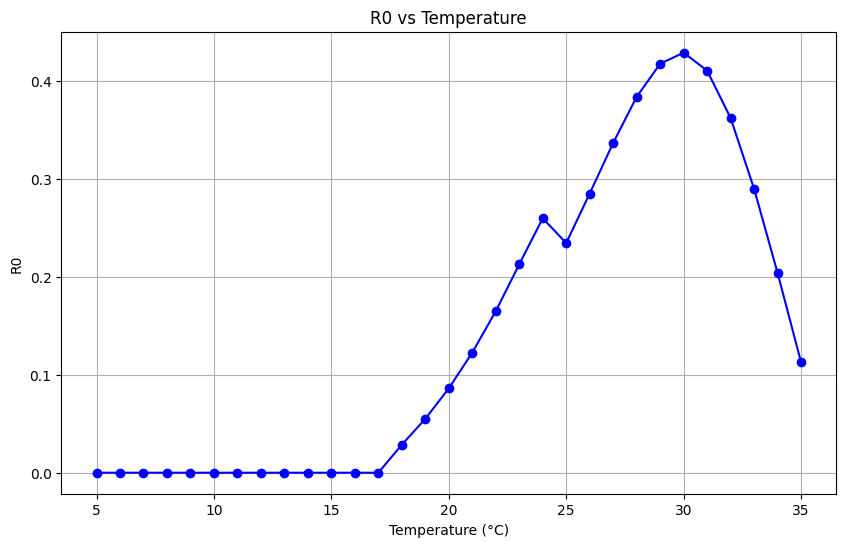

In [10]:
temperatures = np.arange(5, 36, 1)

# Compute R0 for each temperature and print details
r0_values = []
for T in temperatures:
    r0, diag = calculate_r0(params, T)
    r0 = r0 if not np.isnan(r0) else 0.0
    r0_values.append(r0)
    
    print(f"\nTemperature: {T}°C")
    print(f"R0 (spectral radius): {r0:.4f}")
    print(f"R_mh (mosquito-to-human): {diag['R_mh']:.4f}")
    print(f"R_hm (human-to-mosquito): {diag['R_hm']:.4f}")
    print(f"R0 from sqrt(R_mh * R_hm): {diag['R0_sqrt']:.4f}")
    print("Next Generation Matrix (KL):\n", diag['KL'])
    print("Major Eigenvector:\n", diag['major_eigvec'])

# Code for line plot of R0 vs Temperature
plt.figure(figsize=(10, 6))
plt.plot(temperatures, r0_values, marker='o', linestyle='-', color='b')
plt.title('R0 vs Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('R0')
plt.grid(True)
plt.show()